<a href="https://colab.research.google.com/github/MuhammadRibhiRamadan/fsi-prediction-id/blob/main/DSAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Machine Learning-Based Prediction of Food Security Index Using Food Prices and Socioeconomic Indicators in Indonesia**

# **Import Library**

In [410]:
import pandas as pd          # for data manipulation and analysis
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt   # for basic data visualization
import seaborn as sns        # for advanced statistical visualization
from sklearn.model_selection import train_test_split  # for splitting dataset into training and testing sets

In [411]:
# this step is used to connect Google Colab with Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Collection and Loading**

# Reading Dataset

World Bank (WB)

In [412]:
food_df = pd.read_csv('/content/drive/MyDrive/ProjectDSAI/IDN_RTFP_mkt_2007_2026-04-08.csv')

food_df.head()

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-01-01,2007,...,9855.73,10080.27,NaN,8.8,0.62,0.63,0.62,0.62,NaN,9.2
1,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-02-01,2007,...,9888.89,10105.85,NaN,8.8,0.63,0.64,0.62,0.62,NaN,9.2
2,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-03-01,2007,...,9987.67,10237.43,NaN,8.8,0.62,0.63,0.61,0.63,NaN,9.2
3,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-04-01,2007,...,10101.85,10152.65,NaN,8.8,0.63,0.64,0.62,0.64,NaN,9.2
4,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-05-01,2007,...,9910.64,9910.64,NaN,8.8,0.64,0.65,0.63,0.63,NaN,9.2


Food Security and Vulnerability Atlas (FSVA)

In [413]:
year_data = [2020, 2021, 2022, 2023, 2024, 2025]
data_fsva = []

for year in year_data:
    file = f'/content/drive/MyDrive/ProjectDSAI/tabel_data ({year}).csv'
    year_fsva_df = pd.read_csv(file)
    year_fsva_df['year'] = year
    data_fsva.append(year_fsva_df)

fsva_concat_df = pd.concat(data_fsva, ignore_index=True)

Badan Pusat Statistik (BPS)

In [414]:
year_data = [2020, 2021, 2022, 2023, 2024, 2025]

data_pov_bps = []
data_pop_bps = []

for year in year_data:
    # Total Poverty
    pov_file = f'/content/drive/MyDrive/ProjectDSAI/Jumlah dan Persentase Penduduk Miskin Menurut Provinsi, {year}.csv'
    pov_bps_df = pd.read_csv(pov_file)
    pov_bps_df['year'] = year
    data_pov_bps.append(pov_bps_df)

    # Total Population
    pop_file = f'/content/drive/MyDrive/ProjectDSAI/pop_{year}.csv'
    pop_bps_df = pd.read_csv(pop_file)
    pop_bps_df['year'] = year
    data_pop_bps.append(pop_bps_df)

pov_concat_df = pd.concat(data_pov_bps, ignore_index=True)
pop_concat_df = pd.concat(data_pop_bps, ignore_index=True)

# **Initial Data Analysis (IDA)**

In [415]:
# check the shape (number of rows and columns) of each dataset
print(food_df.shape)
print(fsva_concat_df.shape)
print(pov_concat_df.shape)
print(pop_concat_df.shape)

# check missing values in each dataset
print(food_df.isna().sum())
print(fsva_concat_df.isna().sum())
print(pov_concat_df.isna().sum())
print(pop_concat_df.isna().sum())

(51736, 95)
(3084, 15)
(232, 8)
(255, 7)
ISO3                             0
country                          0
adm1_name                        0
adm2_name                        0
mkt_name                         0
                              ... 
h_food_price_index               0
l_food_price_index               0
c_food_price_index               0
inflation_food_price_index    2676
trust_food_price_index           0
Length: 95, dtype: int64
Wilayah                              0
Komposit                             0
NCPR                               514
Kemiskinan (%)                     514
Pengeluaran Pangan (%)             514
Tanpa Listrik (%)                  514
Tanpa Air Bersih (%)               514
Lama Sekolah Perempuan (tahun)     514
Rasio Tenaga Kesehatan             514
Angka Harapan Hidup (tahun)        514
Stunting (%)                       514
IKP                                  0
IKP Ranking                        514
Unnamed: 13                       3084
yea

# **Dataset Cleaning**

Food Prices (WB)

In [416]:
food_df.head()
food_df.columns

Index(['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon',
       'geo_id', 'price_date', 'year', 'month', 'currency', 'components',
       'start_dense_data', 'last_survey_point', 'data_coverage',
       'data_coverage_recent', 'index_confidence_score',
       'spatially_interpolated', 'chili', 'eggs', 'garlic', 'meat_beef',
       'meat_chicken', 'meat_chicken_broiler', 'oil', 'onions', 'rice',
       'sugar', 'o_chili', 'h_chili', 'l_chili', 'c_chili', 'inflation_chili',
       'trust_chili', 'o_eggs', 'h_eggs', 'l_eggs', 'c_eggs', 'inflation_eggs',
       'trust_eggs', 'o_garlic', 'h_garlic', 'l_garlic', 'c_garlic',
       'inflation_garlic', 'trust_garlic', 'o_meat_beef', 'h_meat_beef',
       'l_meat_beef', 'c_meat_beef', 'inflation_meat_beef', 'trust_meat_beef',
       'o_meat_chicken', 'h_meat_chicken', 'l_meat_chicken', 'c_meat_chicken',
       'inflation_meat_chicken', 'trust_meat_chicken',
       'o_meat_chicken_broiler', 'h_meat_chicken_broiler',
       '

In [417]:
# filter data
food_df = food_df[food_df['adm1_name'] != 'Market Average']
food_df = food_df[food_df['year'].between(2020, 2025)]

In [418]:
# rename columns
food_df = food_df.rename(columns={
    'adm1_name': 'province',
    'c_chili': 'chili_price',
    'c_eggs': 'eggs_price',
    'c_garlic': 'garlic_price',
    'c_meat_beef': 'beef_price',
    'c_meat_chicken': 'chicken_price',
    'c_meat_chicken_broiler': 'chicken_broiler_price',
    'c_oil': 'oil_price',
    'c_onions': 'onions_price',
    'c_rice': 'rice_price',
    'c_sugar': 'sugar_price'
})

In [419]:
# select price columns
food_price_col = [col for col in food_df.columns if col.endswith('_price')]

In [420]:
# aggregate annual data per province
food_clean = (
    food_df
    .groupby(['province', 'year'])[food_price_col]
    .median()
    .reset_index()
)

In [421]:
# normalize province names
food_clean['province'] = food_clean['province'].str.upper().str.strip()

In [422]:
# check cleaned food dataset
print(food_clean.shape)
print(food_clean.columns.tolist())
food_clean.head()

(204, 12)
['province', 'year', 'chili_price', 'eggs_price', 'garlic_price', 'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price', 'onions_price', 'rice_price', 'sugar_price']


,province,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
0,ACEH,2020,32454.775,24277.195,27873.405,133545.040,28688.150,27966.310,13926.885,37454.915,10071.950,14370.070
1,ACEH,2021,37695.300,24856.380,26878.910,143272.525,29233.695,28676.815,15393.135,33084.295,9900.000,13500.000
2,ACEH,2022,48638.840,27860.225,26586.135,147054.050,29948.165,30000.000,20319.235,35890.205,10323.065,14730.835
3,ACEH,2023,40100.000,29049.070,34445.765,150791.765,30017.045,29906.250,19000.000,34450.700,12111.050,15000.000
4,ACEH,2024,48971.650,28684.690,40000.000,150606.960,31113.200,31360.535,20000.000,37246.500,13755.110,18000.000


In [423]:
# check number of provinces per year
food_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [424]:
# check duplicate entries per province and year
food_clean.duplicated(subset=['province', 'year']).sum()

np.int64(0)

In [425]:
# check missing values in food_clean
food_clean.isna().sum()

,0
province,0
year,0
chili_price,0
eggs_price,0
garlic_price,0
beef_price,0
chicken_price,0
chicken_broiler_price,0
oil_price,0
onions_price,0


In [426]:
# summary statistics of food_clean
food_clean.describe()

,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
count,204.000000,204.00000,204.000000,204.000000,204.00000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2022.500000,49233.27451,28096.788578,35371.795343,133251.23723,35533.214730,35602.822255,18551.679730,37500.443456,13291.866887,15515.478382
std,1.712026,14256.65571,3643.733919,7502.939289,13186.51456,4878.990707,5078.950079,3345.841048,6656.485768,2124.665585,2061.428846
min,2020.000000,24351.47000,21012.745000,20858.225000,94806.54500,25361.415000,24716.080000,12482.135000,24000.000000,8884.285000,11265.370000
25%,2021.000000,38086.39875,25337.731250,28508.361250,124956.59625,32036.995000,32093.207500,15427.226250,33165.782500,11540.575000,14005.246250
50%,2022.500000,48195.21750,28000.000000,35017.942500,133200.72750,35137.697500,35464.752500,19090.692500,36340.560000,13250.000000,15000.000000
75%,2024.000000,57714.01750,30290.667500,40659.492500,141176.34875,38635.041250,38855.447500,21000.000000,40280.666250,14724.795000,17750.000000
max,2025.000000,85728.54500,37472.875000,59896.330000,164386.53000,46647.730000,47154.555000,28750.000000,65000.000000,18418.650000,21000.000000


In [427]:
sorted(food_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DAERAH ISTIMEWA YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

**Food Security Index (FSVA)**





In [428]:
# handle different structure
if 'Komposit' in fsva_concat_df.columns:
    pass
else:
    raise ValueError("Komposit column not found")

fsva_concat_df = fsva_concat_df[['Wilayah', 'Komposit', 'IKP', 'year']]

In [429]:
# extract province name
fsva_concat_df['province'] = fsva_concat_df['Wilayah'].str.split(' - ').str[0]


In [430]:
# normalize province format
fsva_concat_df['province'] = fsva_concat_df['province'].str.upper().str.strip()

In [431]:
# convert data types to numeric
fsva_concat_df['IKP'] = pd.to_numeric(fsva_concat_df['IKP'], errors='coerce')
fsva_concat_df['Komposit'] = pd.to_numeric(fsva_concat_df['Komposit'], errors='coerce')

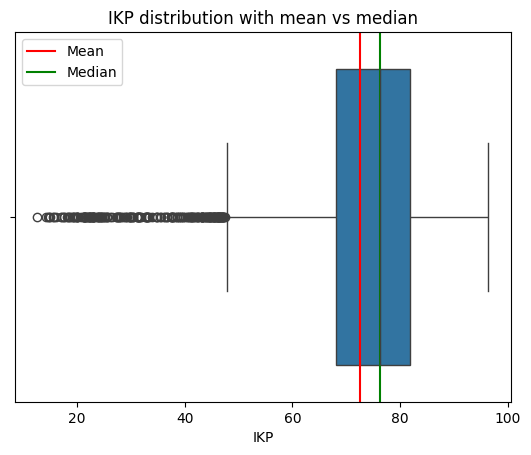

In [432]:
# explore IKP distribution
fsva_concat_df['IKP'].describe()

sns.boxplot(x=fsva_concat_df['IKP'])
plt.axvline(fsva_concat_df["IKP"].mean(), color='red', label='Mean')
plt.axvline(fsva_concat_df["IKP"].median(), color='green', label='Median')

plt.legend()
plt.title("IKP distribution with mean vs median")

plt.show()

In [433]:
# aggregate to province level
fsva_clean = (
    fsva_concat_df
    .groupby(['province', 'year'])[['Komposit', 'IKP']]
    .median()
    .reset_index()
)

In [434]:
# rename columns
fsva_clean.rename(columns={
    'Komposit': 'fsi',
    'IKP': 'fsi_score'
}, inplace=True)

In [435]:
# check fsva_clean
print(fsva_clean.head())
print(fsva_clean.shape)

  province  year  fsi  fsi_score
0     ACEH  2020  5.0      74.57
1     ACEH  2021  6.0      76.08
2     ACEH  2022  5.0      74.63
3     ACEH  2023  6.0      76.66
4     ACEH  2024  6.0      77.19
(204, 4)


In [436]:
# check number of provinces per year
fsva_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


**Poverty and Population Data (BPS)**

In [437]:
# rename poverty data columns
pov_concat_df  = pov_concat_df.rename(columns={
    'Provinsi': 'province',
    'Garis Kemiskinan - Maret (Rp)': 'poverty_line',
    'Jumlah Penduduk Miskin - Maret (ribu) (Ribu)': 'poor_population',
    'Persentase Penduduk Miskin - Maret': 'poverty_rate'
})

In [438]:
# rename population data columns
pop_concat_df = pop_concat_df.rename(columns={
    'Provinsi': 'province',
    'Jumlah Penduduk (Ribu)': 'total_population'
})

In [439]:
# clean string
for df in [pov_concat_df , pop_concat_df]:
    df['province'] = df['province'].astype(str).str.upper().str.strip()

In [440]:
# filter invalid rows
pov_concat_df  = pov_concat_df [
    (~pov_concat_df['province'].str.contains('INDONESIA', na=False)) &
    (~pov_concat_df ['province'].str.contains('CATATAN', na=False)) &
    (~pov_concat_df['province'].str.contains('TIDAK DILAKUKAN', na=False)) &
    (pov_concat_df['province'] != '-') &
    (pov_concat_df['province'] != 'NAN')
]

In [441]:
# debug province names
[x for x in pov_concat_df['province'].unique() if 'INDO' in x]

[]

In [442]:
# merge poverty data with population data
pov_concat_df = pov_concat_df.merge(
    pop_concat_df[['province', 'year', 'total_population']],
    on=['province', 'year'],
    how='left'
)

In [443]:
# map Papua regions to original provinces
def map_province(p):
    if p in ['PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']:
        return 'PAPUA'
    elif p == 'PAPUA BARAT DAYA':
        return 'PAPUA BARAT'
    else:
        return p

pov_concat_df['province_fix'] = pov_concat_df['province'].apply(map_province)

In [444]:
# check missing population after merge
pov_concat_df[pov_concat_df['total_population'].isna()][['province', 'year']].drop_duplicates()

,province,year
101,PAPUA BARAT DAYA,2022
103,PAPUA SELATAN,2022
104,PAPUA TENGAH,2022
105,PAPUA PEGUNUNGAN,2022


In [445]:
# convert selected columns to numeric
cols = ['total_population', 'poor_population', 'poverty_line']

for col in cols:
    pov_concat_df[col] = (
        pov_concat_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    pov_concat_df[col] = pd.to_numeric(pov_concat_df[col], errors='coerce')

In [446]:
# check data types of selected columns
pov_concat_df[cols].dtypes

,0
total_population,float64
poor_population,float64
poverty_line,float64


In [447]:
# handle missing values
pov_concat_df = pov_concat_df.dropna(subset=['total_population', 'poor_population', 'poverty_line'])

In [448]:
# aggregate to province level
agg_list = []

for (prov, year), group in pov_concat_df.groupby(['province_fix', 'year']):

    total_pop = group['total_population'].sum()
    total_poor = group['poor_population'].sum()

    if total_pop == 0 or pd.isna(total_pop):
        continue

    poverty_rate = (total_poor / total_pop) * 100

    poverty_line = (group['poverty_line'] * group['total_population']).sum() / total_pop

    agg_list.append({
        'province': prov,
        'year': year,
        'poverty_rate': poverty_rate,
        'poverty_line': poverty_line
    })

bps_clean = pd.DataFrame(agg_list)

In [449]:
# check province count, missing values, and shape
print(bps_clean.groupby('year')['province'].nunique())

print(bps_clean.isna().sum())

print(bps_clean.shape)

bps_clean.head()

year
2020    34
2021    34
2022    34
2023    34
2024    34
2025    34
Name: province, dtype: int64
province        0
year            0
poverty_rate    0
poverty_line    0
dtype: int64
(204, 4)


,province,year,poverty_rate,poverty_line
0,ACEH,2020,15.448824,522126.0
1,ACEH,2021,15.640925,541109.0
2,ACEH,2022,14.919285,579227.0
3,ACEH,2023,14.715002,627534.0
4,ACEH,2024,14.483510,661227.0


In [450]:
sorted(bps_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DI YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

# **Data Integration**

**Merging Datasets**

In [451]:
print(fsva_clean.columns)
print(food_clean.columns)
print(bps_clean.columns)

Index(['province', 'year', 'fsi', 'fsi_score'], dtype='object')
Index(['province', 'year', 'chili_price', 'eggs_price', 'garlic_price',
       'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price',
       'onions_price', 'rice_price', 'sugar_price'],
      dtype='object')
Index(['province', 'year', 'poverty_rate', 'poverty_line'], dtype='object')


In [452]:
print(fsva_clean.shape)
print(food_clean.shape)
print(bps_clean.shape)

(204, 4)
(204, 12)
(204, 4)


In [453]:
len(set(fsva_clean['province']))
len(set(food_clean['province']))
len(set(bps_clean['province']))

34

In [454]:
# check province mismatch across datasets
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH',
 'KEP. BANGKA BELITUNG',
 'KEP. RIAU',
 'SULAWESI  TENGGARA'}

In [455]:
# standardize province names
mapping_province = {
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'DI YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA'
}

In [456]:
# apply province name mapping
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = df['province'].replace(mapping_province)

In [457]:
# recheck province mismatch after mapping
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH', 'SULAWESI  TENGGARA'}

In [458]:
# normalize province names format
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = (
        df['province']
        .str.upper()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

In [459]:
# final check for province mismatch
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

set()

In [460]:
# merge datasets
df = fsva_clean.merge(food_clean, on=['province', 'year'], how='inner')
df = df.merge(bps_clean, on=['province', 'year'], how='inner')

In [461]:
# check number of provinces per year after merge
df.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [462]:
# check final dataset shape and preview
df.shape
df.head(204)

,province,year,fsi,fsi_score,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price,poverty_rate,poverty_line
0,ACEH,2020,5.0,74.57,32454.775,24277.195,27873.405,133545.040,28688.150,27966.310,13926.885,37454.915,10071.950,14370.070,15.448824,522126.0
1,ACEH,2021,6.0,76.08,37695.300,24856.380,26878.910,143272.525,29233.695,28676.815,15393.135,33084.295,9900.000,13500.000,15.640925,541109.0
2,ACEH,2022,5.0,74.63,48638.840,27860.225,26586.135,147054.050,29948.165,30000.000,20319.235,35890.205,10323.065,14730.835,14.919285,579227.0
3,ACEH,2023,6.0,76.66,40100.000,29049.070,34445.765,150791.765,30017.045,29906.250,19000.000,34450.700,12111.050,15000.000,14.715002,627534.0
4,ACEH,2024,6.0,77.19,48971.650,28684.690,40000.000,150606.960,31113.200,31360.535,20000.000,37246.500,13755.110,18000.000,14.483510,661227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,SUMATERA UTARA,2021,5.0,74.16,33791.220,24000.000,27832.820,130000.000,33820.940,33794.260,15275.000,30560.160,11250.000,13000.000,8.997335,525756.0
200,SUMATERA UTARA,2022,5.0,71.74,45266.790,26316.015,27139.595,135000.000,33000.000,33486.840,19804.855,35000.000,11554.100,14267.315,8.390164,561004.0
201,SUMATERA UTARA,2023,6.0,76.89,37870.320,28106.495,34825.985,140000.000,32431.530,31399.875,18709.025,31526.720,12984.355,15000.000,8.057076,602999.0
202,SUMATERA UTARA,2024,6.0,77.31,47036.465,28800.000,40000.000,140000.000,33826.040,33831.085,20000.000,38241.850,14114.450,17750.000,7.877666,642423.0


# **Exploratory Data Analysis (EDA)**

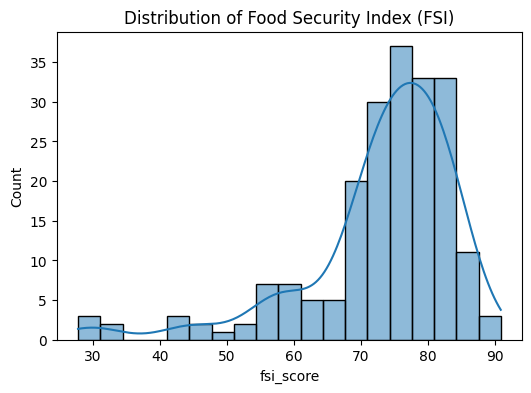

In [463]:
# plot distribution of fsi_score
plt.figure(figsize=(6,4))
sns.histplot(df['fsi_score'], kde=True)
plt.title('Distribution of Food Security Index (FSI)')
plt.show()

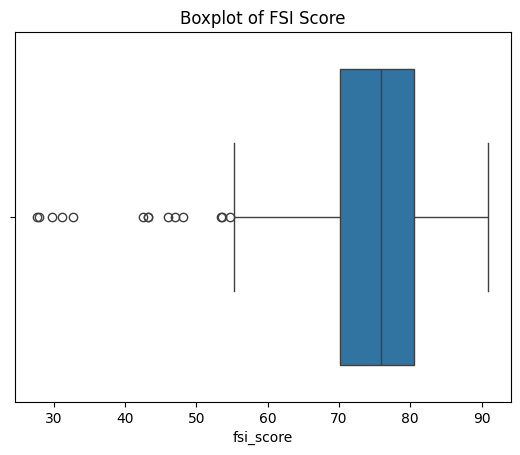

In [464]:
# plot boxplot of fsi_score
sns.boxplot(x=df['fsi_score'])
plt.title('Boxplot of FSI Score')
plt.show()

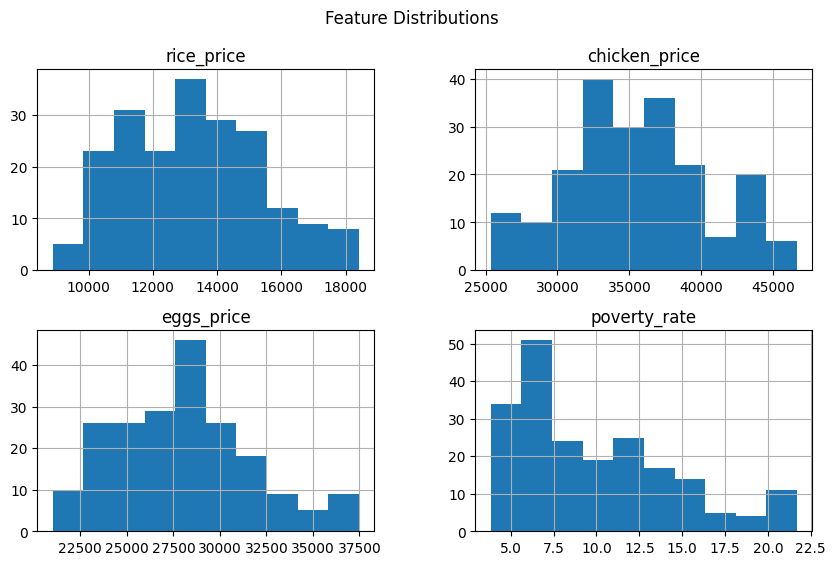

In [465]:
# plot distribution of selected features
features = ['rice_price', 'chicken_price', 'eggs_price', 'poverty_rate']

df[features].hist(figsize=(10,6))
plt.suptitle('Feature Distributions')
plt.show()

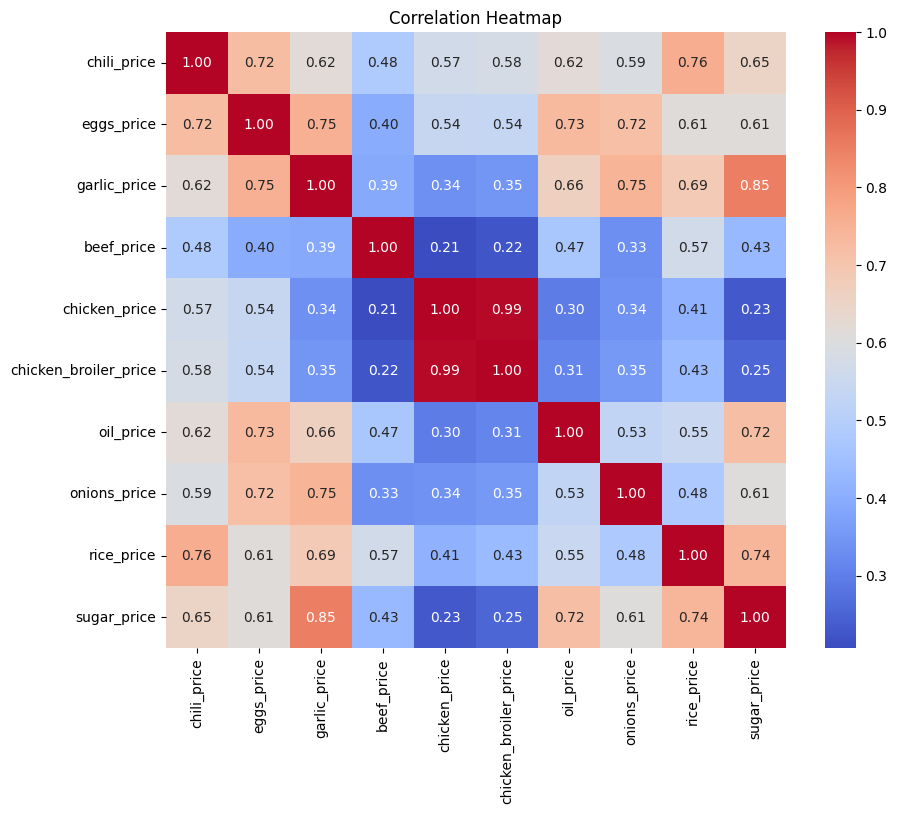

In [466]:
# plot correlation heatmap
corr = food_clean.drop(columns=['province', 'year']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

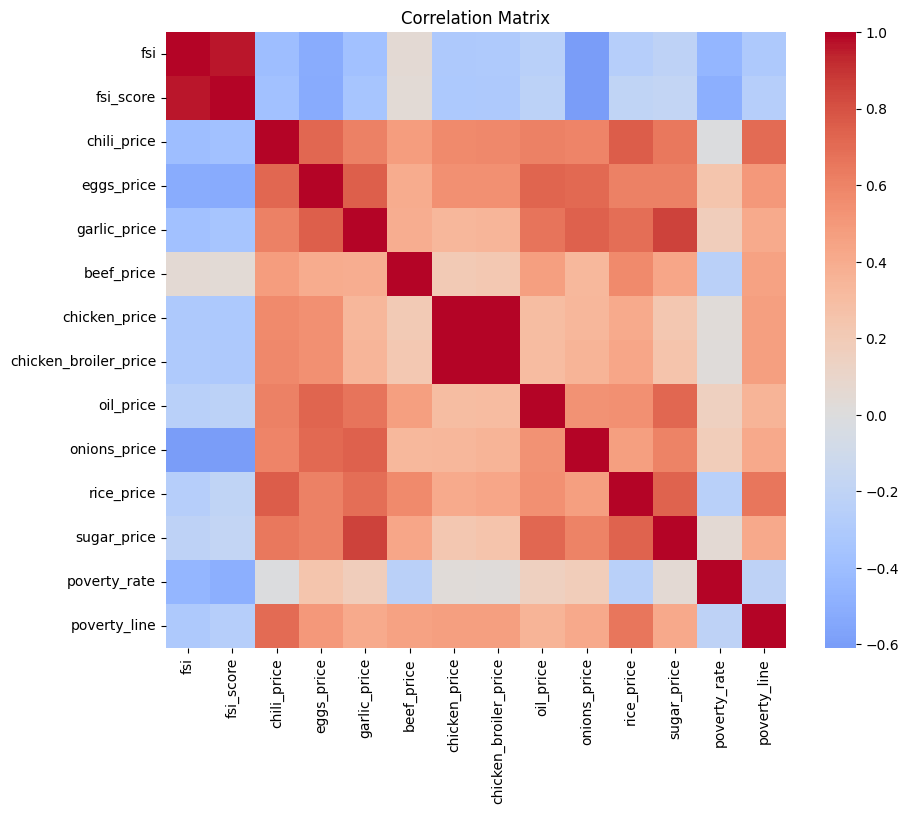

In [467]:
# plot correlation matrix
plt.figure(figsize=(10,8))
corr = df.drop(columns=['province', 'year']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [468]:
# check top correlations with fsi_score
corr = df.drop(columns=['province', 'year', 'fsi']).corr()
corr_target = corr['fsi_score'].drop('fsi_score').sort_values(ascending=False)
print(corr_target.head(10))

beef_price               0.040323
sugar_price             -0.177622
rice_price              -0.195963
oil_price               -0.224737
poverty_line            -0.259258
chicken_broiler_price   -0.304448
chicken_price           -0.310547
garlic_price            -0.348313
chili_price             -0.371098
poverty_rate            -0.501856
Name: fsi_score, dtype: float64


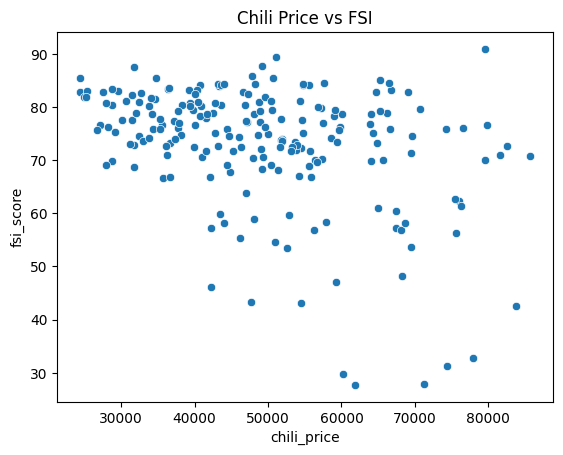

In [469]:
# plot relationship between chili price and fsi_score
sns.scatterplot(x=df['chili_price'], y=df['fsi_score'])
plt.title('Chili Price vs FSI')
plt.show()

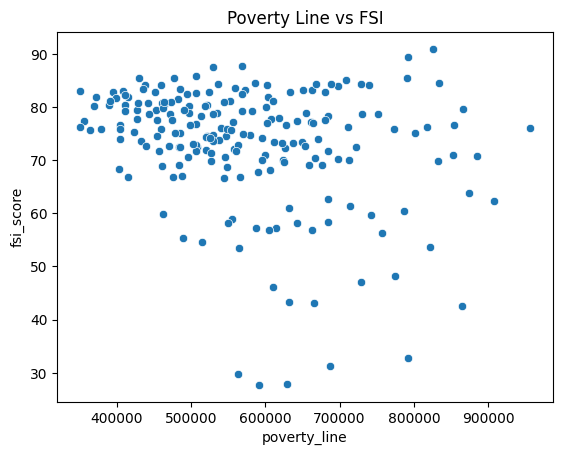

In [470]:
# plot relationship between poverty line and fsi_score
sns.scatterplot(x=df['poverty_line'], y=df['fsi_score'])
plt.title('Poverty Line vs FSI')
plt.show()

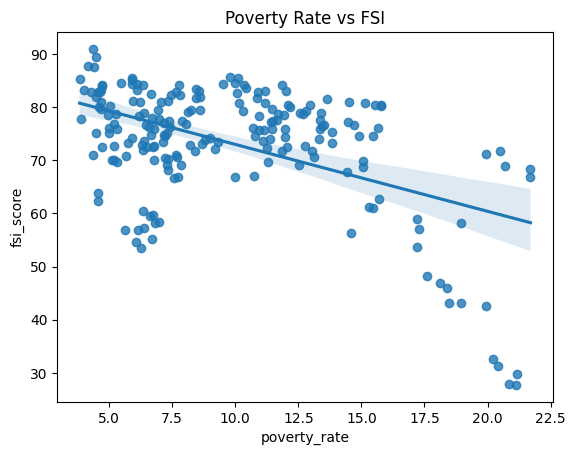

In [471]:
# plot relationship between poverty rate and fsi_score
sns.regplot(x=df['poverty_rate'], y=df['fsi_score'])
plt.title('Poverty Rate vs FSI')
plt.show()

# **Splitting Dataset**

In [472]:
X = df.drop(columns=['fsi_score', 'fsi', 'province'])
y = df['fsi_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [473]:
X_train.dtypes

,0
year,int64
chili_price,float64
eggs_price,float64
garlic_price,float64
beef_price,float64
chicken_price,float64
chicken_broiler_price,float64
oil_price,float64
onions_price,float64
rice_price,float64


# **Feature Preprocessing (Scaling)**

In [474]:
from sklearn.preprocessing import StandardScaler

# Normalization (using StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [475]:
# Final Dataset Check
print(X_train.shape)
print(X_test.shape)
print(pd.DataFrame(X_train).isna().sum().sum())

(163, 13)
(41, 13)
0
